## Part 1

In [ ]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("uciml/indian-liver-patient-records")

# First let's explore the data
df = pd.read_csv(path + "/indian_liver_patient.csv")

# Take a look at some rows and overall numbers across dataset
print("First 5 rows:")
display(df.head())
print("Last 5 rows:")
display(df.tail())
print("Shape:", df.shape,"\n")
print("Info:")
df.info()
print("\nSummary Statistics:")
display(df.describe())

# Missing values or duplicates
print("Null values: \n", df.isnull().sum()) # 4 nulls in Albumin_and_Globulin_Ratio column
print("\nDuplicate rows:", df.duplicated().sum()) # 13 duplicates

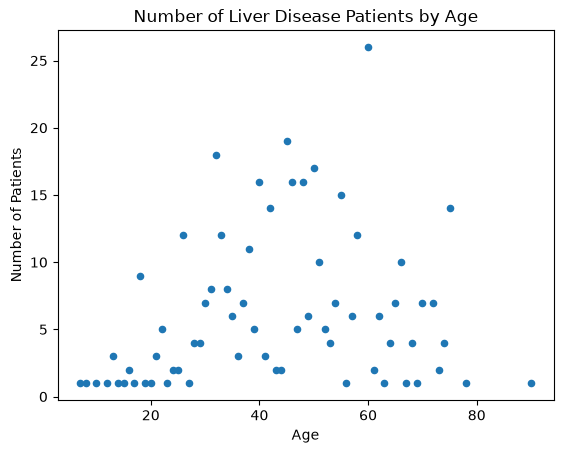

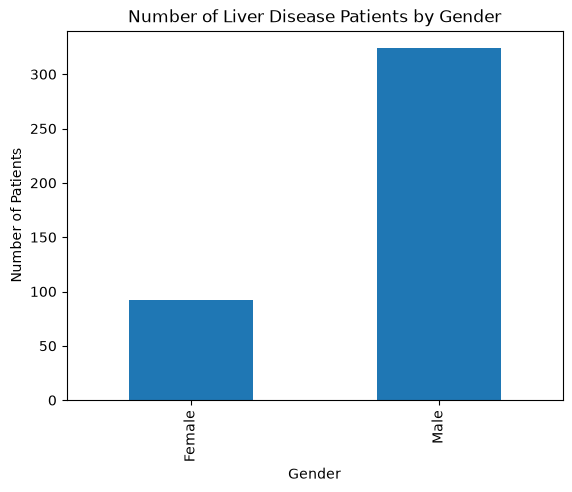

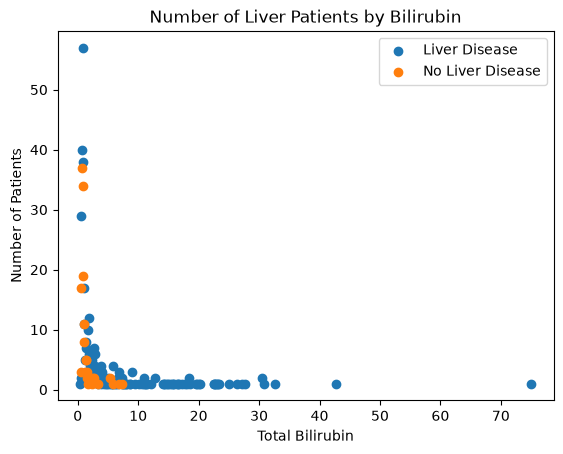

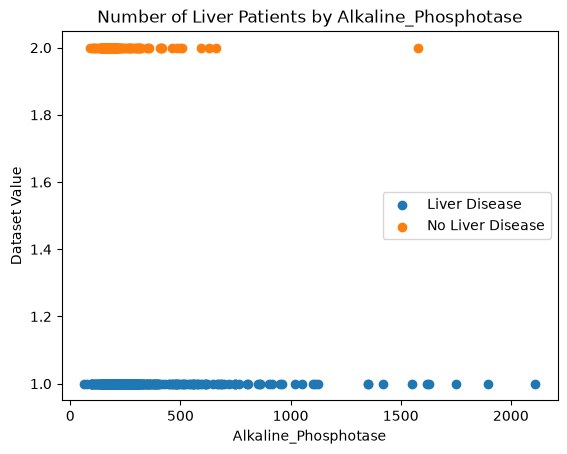

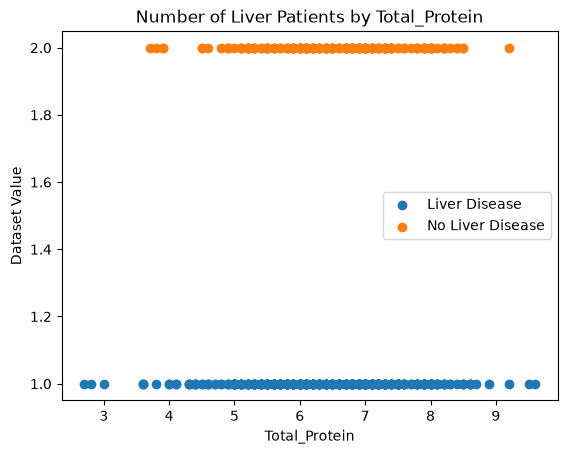

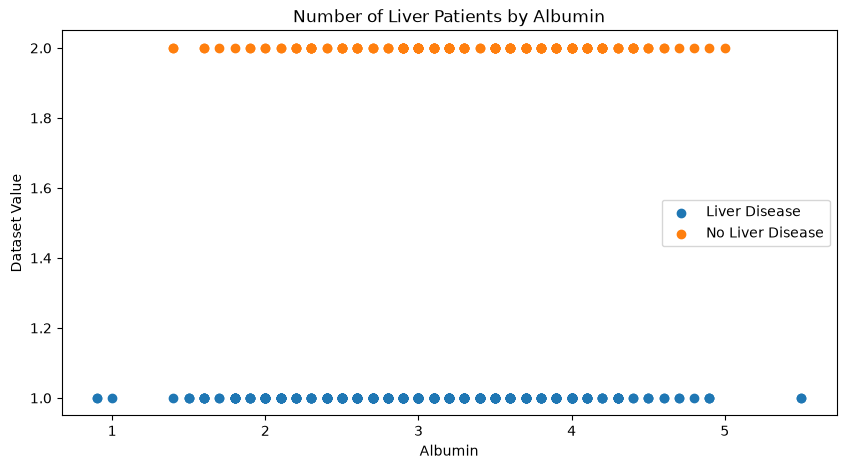

In [143]:
import matplotlib.pyplot as plt

# Create some plots to see how some columns correlate with disease
# Data shows that fewer disease patients are young
age_plot = df.iloc[df['Dataset']==1].groupby('Age')[['Dataset']].count().reset_index() # Queried ChatGPT to find out I needed to reset_index
age_plot.plot(x='Age',y='Dataset', kind='scatter', title='Number of Liver Disease Patients by Age', ylabel='Number of Patients')

# # Data shows that most disease patients are males, could be biased dataset though
gender_plot = df.iloc[df['Dataset']==1].groupby('Gender')[['Dataset']].count().reset_index()
gender_plot.plot(x='Gender', y='Dataset', kind='bar', title='Number of Liver Disease Patients by Gender', ylabel='Number of Patients', legend=False)

# Data shows that patients with higher bilirubin levels are more likely to have liver disease, this makes sense as the liver processes bilirubin
plt.figure()
bilirubin_plot1 = df.iloc[df['Dataset']==1].groupby('Total_Bilirubin')[['Dataset']].count().reset_index()
bilirubin_plot2 = df.iloc[df['Dataset']==2].groupby('Total_Bilirubin')[['Dataset']].count().reset_index()
plt.scatter(bilirubin_plot1['Total_Bilirubin'], bilirubin_plot1['Dataset'], label='Liver Disease')
plt.scatter(bilirubin_plot2['Total_Bilirubin'], bilirubin_plot2['Dataset'], label='No Liver Disease')
plt.xlabel('Total Bilirubin')
plt.ylabel('Number of Patients')
plt.title('Number of Liver Patients by Bilirubin')
plt.legend()
plt.show()

# Data shows that patients with higher Alkaline_Phosphotase levels are more likely to have liver disease
plt.figure()
df_disease = df.iloc[df['Dataset']==1]
df_no_disease = df.iloc[df['Dataset']==2]
plt.scatter(df_disease['Alkaline_Phosphotase'], df_disease['Dataset'], label='Liver Disease')
plt.scatter(df_no_disease['Alkaline_Phosphotase'], df_no_disease['Dataset'], label='No Liver Disease')
plt.xlabel('Alkaline_Phosphotase')
plt.ylabel('Dataset Value')
plt.title('Number of Liver Patients by Alkaline_Phosphotase')
plt.legend()
plt.show()

# Data shows that total protein does not indicate much
plt.figure()
plt.scatter(df_disease['Total_Protiens'], df_disease['Dataset'], label='Liver Disease')
plt.scatter(df_no_disease['Total_Protiens'], df_no_disease['Dataset'], label='No Liver Disease')
plt.xlabel('Total_Protein')
plt.ylabel('Dataset Value')
plt.title('Number of Liver Patients by Total_Protein')
plt.legend()
plt.show()

# Data shows that Albumin does not indicate much
plt.figure(figsize=(10,5))
plt.scatter(df_disease['Albumin'], df_disease['Dataset'], label='Liver Disease')
plt.scatter(df_no_disease['Albumin'], df_no_disease['Dataset'], label='No Liver Disease')
plt.xlabel('Albumin')
plt.ylabel('Dataset Value')
plt.title('Number of Liver Patients by Albumin')
plt.legend()
plt.show()

Bilirubin Outliers:



,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
22,62,Male,6.8,3.0,542,116,66,6.4,3.1,0.90,1
27,34,Male,6.2,3.0,240,1680,850,7.2,4.0,1.20,1
37,46,Female,14.2,7.8,374,38,77,4.3,2.0,0.80,1
...,...,...,...,...,...,...,...,...,...,...,...
572,32,Male,15.6,9.5,134,54,125,5.6,4.0,2.50,1
574,32,Male,12.1,6.0,515,48,92,6.6,2.4,0.50,1
575,32,Male,25.0,13.7,560,41,88,7.9,2.5,2.50,1
576,32,Male,15.0,8.2,289,58,80,5.3,2.2,0.70,1


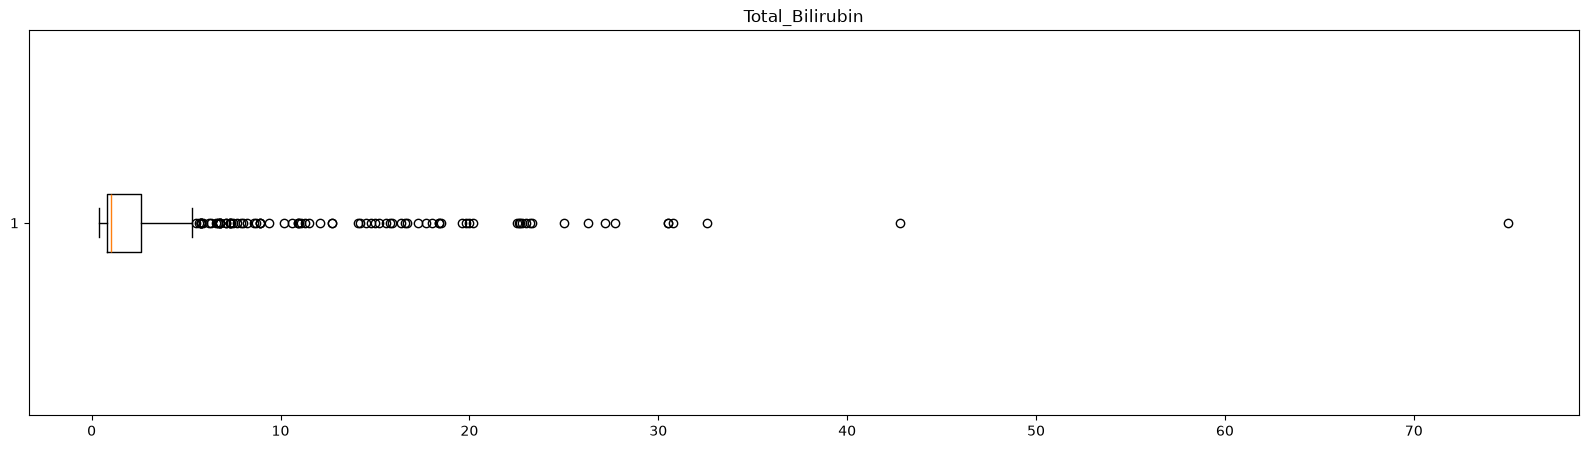

Alkaline_Phosphotase Outliers:



,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
20,51,Male,2.2,1.0,610,17,28,7.3,2.6,0.55,1
21,51,Male,2.9,1.3,482,22,34,7.0,2.4,0.50,1
22,62,Male,6.8,3.0,542,116,66,6.4,3.1,0.90,1
...,...,...,...,...,...,...,...,...,...,...,...
549,40,Female,2.1,1.0,768,74,141,7.8,4.9,1.60,1
573,32,Male,3.7,1.6,612,50,88,6.2,1.9,0.40,1
574,32,Male,12.1,6.0,515,48,92,6.6,2.4,0.50,1
575,32,Male,25.0,13.7,560,41,88,7.9,2.5,2.50,1


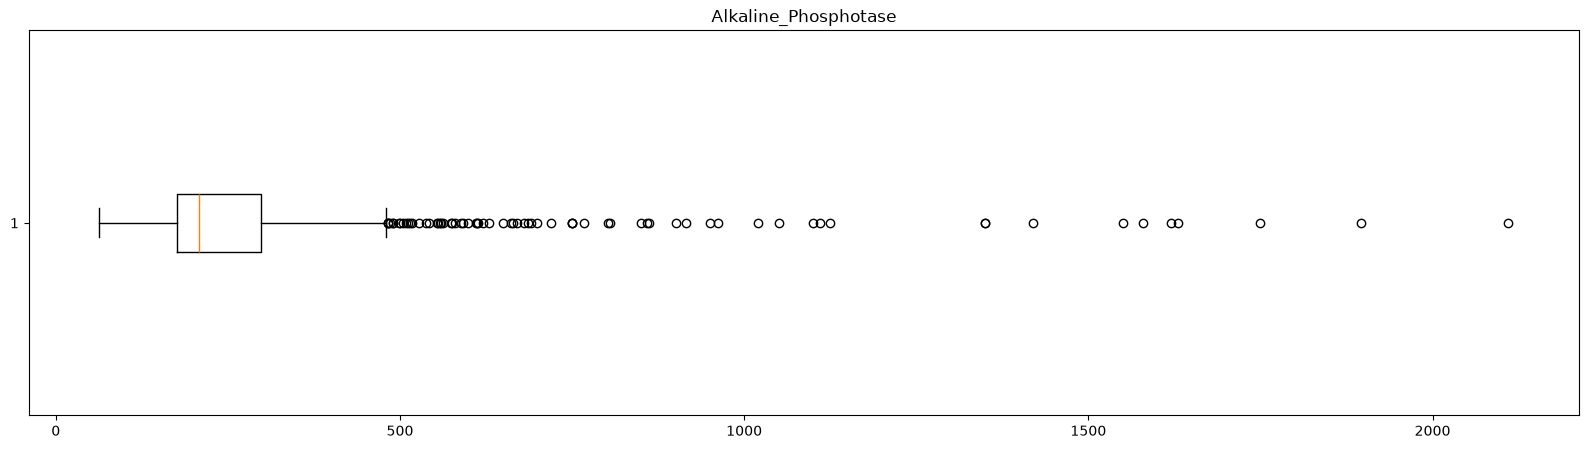

Alamine_Aminotransferase Outliers:



,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
16,38,Male,1.8,0.8,342,168,441,7.6,4.4,1.3,1
18,40,Female,0.9,0.3,293,232,245,6.8,3.1,0.8,1
19,40,Female,0.9,0.3,293,232,245,6.8,3.1,0.8,1
25,34,Male,4.1,2.0,289,875,731,5.0,2.7,1.1,1
26,34,Male,4.1,2.0,289,875,731,5.0,2.7,1.1,1
...,...,...,...,...,...,...,...,...,...,...,...
560,66,Male,15.2,7.7,356,321,562,6.5,2.2,0.4,1
561,66,Male,16.6,7.6,315,233,384,6.9,2.0,0.4,1
562,66,Male,17.3,8.5,388,173,367,7.8,2.6,0.5,1
569,16,Male,7.7,4.1,268,213,168,7.1,4.0,1.2,1


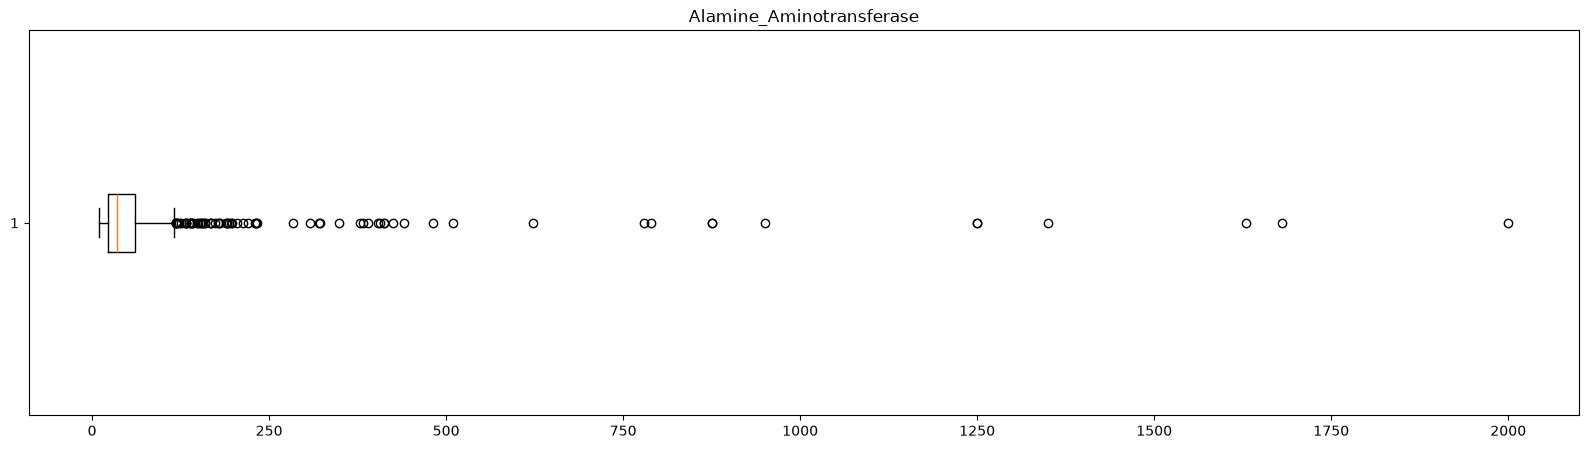

Total_Protiens Outliers:



,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
180,75,Male,2.8,1.3,250,23,29,2.7,0.9,0.5,1
181,75,Male,2.9,1.3,218,33,37,3.0,1.5,1.0,1
269,26,Male,0.6,0.1,110,15,20,2.8,1.6,1.3,1
270,37,Male,0.7,0.2,235,96,54,9.5,4.9,1.0,1
273,30,Male,0.7,0.2,262,15,18,9.6,4.7,1.2,1
415,70,Male,1.3,0.3,690,93,40,3.6,2.7,0.7,1
458,26,Male,6.8,3.2,140,37,19,3.6,0.9,0.3,1
533,46,Female,1.4,0.4,298,509,623,3.6,1.0,0.3,1


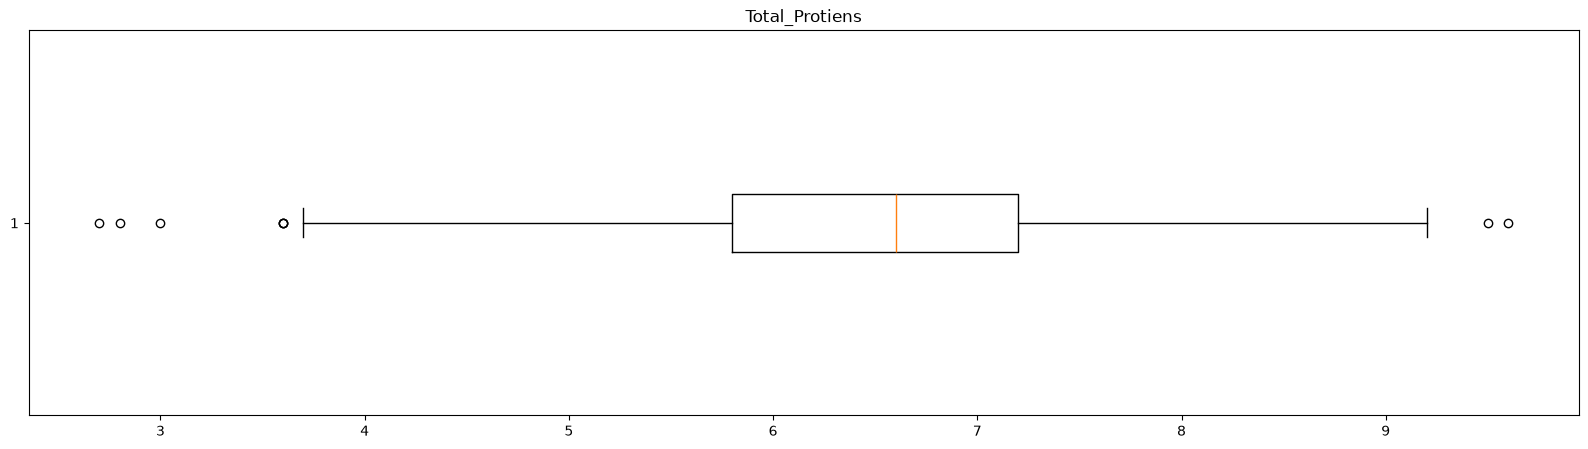

In [171]:
import numpy as np

# Detect anomalies with IQR, Total bilirubin
Q1 = df['Total_Bilirubin'].quantile(0.25)
Q3 = df['Total_Bilirubin'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
bilirubin_outliers = df[(df['Total_Bilirubin'] < lower) | (df['Total_Bilirubin'] > upper)]
print("Bilirubin Outliers:\n")
display(bilirubin_outliers)
fig, ax = plt.subplots(figsize=(20,5))
ax.boxplot(df['Total_Bilirubin'], orientation='horizontal')
ax.set_title('Total_Bilirubin')
plt.show()

# Alkaline Phosphotase
Q1 = df['Alkaline_Phosphotase'].quantile(0.25)
Q3 = df['Alkaline_Phosphotase'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
alkaline_phosphotase_outliers = df[(df['Alkaline_Phosphotase'] < lower) | (df['Alkaline_Phosphotase'] > upper)]
print("Alkaline_Phosphotase Outliers:\n")
display(alkaline_phosphotase_outliers)
fig, ax = plt.subplots(figsize=(20,5))
ax.boxplot(df['Alkaline_Phosphotase'], orientation='horizontal')
ax.set_title('Alkaline_Phosphotase')
plt.show()

# Alamine_Aminotransferase
Q1 = df['Alamine_Aminotransferase'].quantile(0.25)
Q3 = df['Alamine_Aminotransferase'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
alamine_aminotransferase_outliers = df[(df['Alamine_Aminotransferase'] < lower) | (df['Alamine_Aminotransferase'] > upper)]
print("Alamine_Aminotransferase Outliers:\n")
display(alamine_aminotransferase_outliers)
fig, ax = plt.subplots(figsize=(20,5))
ax.boxplot(df['Alamine_Aminotransferase'], orientation='horizontal')
ax.set_title('Alamine_Aminotransferase')
plt.show()

# Total_Protiens
Q1 = df['Total_Protiens'].quantile(0.25)
Q3 = df['Total_Protiens'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
total_protiens_outliers = df[(df['Total_Protiens'] < lower) | (df['Total_Protiens'] > upper)]
print("Total_Protiens Outliers:\n")
display(total_protiens_outliers)
fig, ax = plt.subplots(figsize=(20,5))
ax.boxplot(df['Total_Protiens'], orientation='horizontal')
ax.set_title('Total_Protiens')
plt.show()